<a href="https://colab.research.google.com/github/mateosuster/veranito_pythonico/blob/main/modulo2/Practica_2_3_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica de Análisis Exploratorio de Datos (EDA)


## Machete

* La **población** es el conjunto completo de elementos con características
en común y que se quiere estudiar.

* Una **muestra** es un subconjunto representativo de la población, cuyo menor tamaño la hace más fácil de manejar.

* A las poblaciones por lo general se las estudia a través de una muestra cuidadosamente seleccionada. Por extensión, las características de la muestra corresponden a las de población dentro un estrecho margen, que el investigador establece usando técnicas estadísticas.

* $\mu$ es la **media** poblacional, es una medida de tendencia central. Es la media aritmética de todos los elementos de la población.

* $\sigma$ es la **desviación estándar** poblacional, es un índice numérico de la dispersión de un conjunto de datos. Mide la variabilidad absoluta de la distribución de un conjunto de datos.

* $\bar{X}$ es la media muestral (promedio) de la variable aleatoria $𝐗$

## Librerias

In [1]:
#Manipulacion de datos y funciones matemáticas
import pandas as pd
import numpy as np

#Cálculos estadísticos
from scipy.stats import pearsonr

#Visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt

#Control de experimentos aleatorios
import random


## Caso de uso: Spotify dataset

Trabajaremos dos datasets de Spotify: uno con datos de canciones (tracks) y otro de artistas (artists), los cuales iremos explorando a la par. La descripción de los features, asi como otra metadata de utilidad puede encontrarse en el siguiente link: https://developer.spotify.com/documentation/web-api/reference/#/

* Descripción de variables de tracks: https://developer.spotify.com/documentation/web-api/reference/#/operations/get-several-audio-features

* Descripción de variables de artist: https://developer.spotify.com/documentation/web-api/reference/#/operations/get-an-artist


In [2]:
#Cargamos los Datasets
df_artists = pd.read_csv('/content/artists.csv')
df_tracks = pd.read_csv('/content/tracks.csv')

## Tracks data

In [3]:
df_tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          58

In [4]:
df_tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


## Conversión columna a índice

Podemos setear a la variable *id* como índice de todo el dataset con `set_index()`.

In [44]:
df_tracks = df_tracks.set_index('id')
df_tracks.head()

,track_name,popularity,duration_ms,explicit,artists,id_artists,release_date,year,month,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
id,,,,,,,,,,,,,,,,,,,,,
35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,Uli,['45tIt06XoI0Iio4LBEVpls'],1922-02-22,1922,2,0.645,...,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,Fernando Pessoa,['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,1922,6,0.695,...,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,Ignacio Corsini,['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,1922,3,0.434,...,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,Ignacio Corsini,['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,1922,3,0.321,...,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,Dick Haymes,['3BiJGZsyX9sJchTqcSA7Su'],1922-01-01,1922,1,0.402,...,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


Esto puede ser de utilidad para facilitar el filtrado del dataset si yo conozco algún índice particular.

In [46]:
df_tracks.loc['5bJ1DrEM4hNCafcDd1oxHx']

,5bJ1DrEM4hNCafcDd1oxHx
track_name,Self Care
popularity,80
duration_ms,345133
explicit,1
artists,Mac Miller
id_artists,['4LLpKhyESsyAXpc4laK94U']
release_date,2018-08-03 00:00:00
year,2018
month,8
danceability,0.52


Para revertir esta transformación, su inversa es `reset_index()`.

In [47]:
df_tracks.reset_index(inplace=True)

## Definiendo el problema

A partir de los visto en la superficie de los datos, ¿qué preguntas nos interesaría responder?

Imaginemos que queremos iniciarnos en la industria musical y buscamos detectar a talentos musicales. Para eso necesitamos estar familiarizados con los datos. Algunas preguntas pueden ser:

* ¿Qué canciones son las más populares entre los usuarios de Spotify?
* ¿Qué canciones lanzadas en una determinada fecha ganaron popularidad mayor a 80 puntos?
* ¿Existe una correlación entre la popularidad y los features de una canción?
* ¿Cuánto debería durar una canción media según los estándares actuales? ¿Cómo ha cambiado la duración de las canciones a lo largo del tiempo?



## Análisis descriptivos básicos

Pandas viene con algunas funciones built-in para ayudar al análisis descriptivo.



### Para las variables numéricas

In [8]:
df_tracks.describe()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,586672.000000,5.866720e+05,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000
mean,27.570053,2.300512e+05,0.044086,0.563594,0.542036,5.221603,-10.206067,0.658797,0.104864,0.449863,0.113451,0.213935,0.552292,118.464857,3.873382
std,18.370642,1.265261e+05,0.205286,0.166103,0.251923,3.519423,5.089328,0.474114,0.179893,0.348837,0.266868,0.184326,0.257671,29.764108,0.473162
min,0.000000,3.344000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,1.750930e+05,0.000000,0.453000,0.343000,2.000000,-12.891000,0.000000,0.034000,0.096900,0.000000,0.098300,0.346000,95.600000,4.000000
50%,27.000000,2.148930e+05,0.000000,0.577000,0.549000,5.000000,-9.243000,1.000000,0.044300,0.422000,0.000024,0.139000,0.564000,117.384000,4.000000
75%,41.000000,2.638670e+05,0.000000,0.686000,0.748000,8.000000,-6.482000,1.000000,0.076300,0.785000,0.009550,0.278000,0.769000,136.321000,4.000000
max,100.000000,5.621218e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.971000,0.996000,1.000000,1.000000,1.000000,246.381000,5.000000


### Para las variables categóricas


In [9]:
df_artists['genres'].unique()

array(['[]', "['carnaval cadiz']", "['classical harp', 'harp']", ...,
       "['alternative dance', 'dance-punk', 'electrofox', 'new rave', 'swedish electropop']",
       "['emoviolence', 'metallic hardcore']",
       "['australian post-hardcore', 'metallic hardcore']"], dtype=object)

In [49]:
df_artists['genres'].value_counts()

,count
genres,
[],805733
['background piano'],293
['calming instrumental'],255
['background music'],245
['barnmusik'],224
...,...
"['contemporary jazz', 'cool jazz', 'ecm-style jazz', 'jazz', 'jazz fusion', 'jazz vibraphone']",1
"['metallic hardcore', 'pennsylvania hardcore', 'progressive deathcore']",1
"['alternative r&b', 'canadian contemporary r&b', 'chill r&b', 'indie r&b', 'montreal indie']",1


#### Tablas de frecuencia cruzada

In [11]:
pd.crosstab(df_tracks['artists'], df_tracks['explicit']).sort_values(1, ascending = False).head(10)

explicit,0,1
artists,,
['Grazhdanskaya Oborona'],181,168
['Eminem'],9,133
['Sektor Gaza'],31,100
['Drake'],12,91
['2Pac'],12,84
['Daniel Landa'],30,76
['Kanye West'],10,75
['Booba'],2,74
['Eddie Meduza'],267,63


## Detección de valores faltantes

La detección de valores faltantes, missings o NA (not available) es fundamental en la tarea exploratoria, dado que, entre otras razones, puede ser un síntoma de falta de calidad de los datos, además de que algunos algoritmos no operan con la presencia de ellos.

La función *isna()* devuelve un conjunto de datos con los booleanos True y False, los cuales luego se pueden sumar. La función *pd.isnull()* puede ser una alternativa.

In [53]:
df_tracks.isna().sum()

,0
id,0
track_name,71
popularity,0
duration_ms,0
explicit,0
artists,0
id_artists,0
release_date,0
year,0
month,0


In [54]:
df_artists['genres'].isna().sum()

np.int64(0)

In [14]:
# pd.isnull()
pd.isnull(df_tracks).sum()#.sum()

,0
id,0
name,71
popularity,0
duration_ms,0
explicit,0
artists,0
id_artists,0
release_date,0
danceability,0
energy,0


Podemos eliminar estos valores missings con la función *.dropna()*, pero en este caso los dejaremos

## Revisión de valores duplicados

In [57]:
df_tracks.duplicated().any()

np.False_

En este caso no se presentan valores duplicados, pero en caso de existir se podrían eliminar con la función *.drop_duplicates()*

## Creación de columnas

Para facilitar las cosas, vamos a convertir la variable *release_date* a fecha. Originalmente, la variable de tiempo es tipo string ("object"), pero podemos convertirla a una variable temporal con la función *date_time()* de Pandas. La creación de nuevas columnas puede hacerse de distintas formas, la más común es la siguiente:

In [16]:
df_tracks["release_date"] = pd.to_datetime(df_tracks["release_date"], format='mixed')

Además, vamos a crear dos nuevas columna, una con los meses y otra con los años, a partir de la variable de fecha creada anteriormente. En este caso, en lugar de asignar una nueva columna definiendo *df_tracks['year']* vamos a utilizar la función *insert()*. Este método nos permite elegir la posición exacta de la nueva columna ( *loc* ). Si lo hubiéramos hecho a la antigua usanza, las nuevas columnas habrían acabado en el último índice posible.

Previo a ello, guardaremos los valores de interés en dos objetos tipo Series usando [`apply`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html) y `lambda`, para poder definir la función en una sóla linea.

In [17]:
year = df_tracks['release_date'].apply(lambda x : x.year)
month = df_tracks['release_date'].apply(lambda x : x.month)

df_tracks.insert(loc=8, column='year', value=year)
df_tracks.insert(loc=9, column='month', value=month)

## Análisis exploratorio


### ¿Cuáles son las canciones más populares?

Hay varias formas de resolver este problema. Una de ellas es con la función de pandas *query()* vista la clase pasada. Se trata de una función de filtrado que permite seleccionar y filtrar las columnas de un dataFrame con una expresión booleana. Es importante señalar que toda la expresión de la función se pasa entre comillas. Luego ordenamos los valores filtrados con la función *sort_vales()*

Es importante tener en cuenta que el método *Dataframe.query()* sólo funciona si el nombre de la columna no tiene espacios vacíos. Así que antes de aplicar el método, los espacios en los nombres de columna deben ser reemplazados por '_'

In [65]:
most_popular = df_tracks.query('popularity>90', inplace=False).sort_values('popularity', ascending=False)
most_popular[:10]

,id,track_name,popularity,duration_ms,explicit,artists,id_artists,release_date,year,month,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
93802,4iJyoBOLtHqaGxP12qzhQI,Peaches (feat. Daniel Caesar & Giveon),100,198082,1,"Justin Bieber, Daniel Caesar, Giveon","['1uNFoZAHBGtllmzznpCI3s', '20wkVLutqVOYrc0kxF...",2021-03-19,2021,3,...,0,-6.181,1,0.1190,0.32100,0.000000,0.4200,0.464,90.030,4
93803,7lPN2DXiMsVn7XUKtOW1CS,drivers license,99,242014,1,Olivia Rodrigo,['1McMsnEElThX1knmY4oliG'],2021-01-08,2021,1,...,10,-8.761,1,0.0601,0.72100,0.000013,0.1050,0.132,143.874,4
93804,3Ofmpyhv5UAQ70mENzB277,Astronaut In The Ocean,98,132780,0,Masked Wolf,['1uU7g3DNSbsu0QjSEqZtEd'],2021-01-06,2021,1,...,4,-6.865,0,0.0913,0.17500,0.000000,0.1500,0.472,149.996,4
92811,6tDDoYIxWvMLTdKpjFkc1B,telepatía,97,160191,0,Kali Uchis,['1U1el3k54VvEUzo3ybLPlM'],2020-12-04,2020,12,...,11,-9.016,0,0.0502,0.11200,0.000000,0.2030,0.553,83.970,4
92810,5QO79kh1waicV47BqGRL3g,Save Your Tears,97,215627,1,The Weeknd,['1Xyo4u8uXC1ZmMpatF05PJ'],2020-03-20,2020,3,...,0,-5.487,1,0.0309,0.02120,0.000012,0.5430,0.644,118.051,4
92813,0VjIjW4GlUZAMYd2vXMi3b,Blinding Lights,96,200040,0,The Weeknd,['1Xyo4u8uXC1ZmMpatF05PJ'],2020-03-20,2020,3,...,1,-5.934,1,0.0598,0.00146,0.000095,0.0897,0.334,171.005,4
93805,7MAibcTli4IisCtbHKrGMh,Leave The Door Open,96,242096,0,"Bruno Mars, Anderson .Paak, Silk Sonic","['0du5cEVh5yTK9QJze8zA0C', '3jK9MiCrA42lLAdMGU...",2021-03-05,2021,3,...,5,-7.964,1,0.0324,0.18200,0.000000,0.0927,0.719,148.088,4
92814,6f3Slt0GbA2bPZlz0aIFXN,The Business,95,164000,0,Tiësto,['2o5jDhtHVPhrJdv3cEQ99Z'],2020-09-16,2020,9,...,8,-7.079,0,0.2320,0.41400,0.019200,0.1120,0.235,120.031,4
91866,60ynsPSSKe6O3sfwRnIBRf,Streets,94,226987,1,Doja Cat,['5cj0lLjcoR7YOSnhnX0Po5'],2019-11-07,2019,11,...,11,-8.433,1,0.0828,0.20800,0.037100,0.3370,0.190,90.028,4
93806,7Bk0uXKk1uPT0XuQbpFzvs,Fiel,94,261667,0,"Los Legendarios, Wisin, Jhay Cortez","['0n6sKrG0xKAf8xmdqeNGke', '3E6xrwgnVfYCrCs0eP...",2021-02-04,2021,2,...,6,-4.407,0,0.0600,0.40700,0.000000,0.1120,0.505,98.005,4


A primera vista, podemos ver que las 10 primeras canciones más populares se publicaron en 2020 o 2021 y que casi la mitad de ellas contienen algún contenido explícito (indicado por el 1 binario en la columna *explicit*).

Para ver si nuestras conclusiones son correctas, ordenemos los valores filtrados y mostremos las columnas de interés.

In [19]:
pop_date = most_popular.sort_values('release_date', ascending=False)
pop_date[['artists', 'name', 'popularity', 'explicit','release_date']][:20]

,artists,name,popularity,explicit,release_date
93802,"['Justin Bieber', 'Daniel Caesar', 'Giveon']",Peaches (feat. Daniel Caesar & Giveon),100,1,2021-03-19
93805,"['Bruno Mars', 'Anderson .Paak', 'Silk Sonic']",Leave The Door Open,96,0,2021-03-05
93815,['Drake'],What’s Next,91,1,2021-03-05
93811,['Justin Bieber'],Hold On,92,0,2021-03-05
93816,['Dua Lipa'],We're Good,91,0,2021-02-11
93809,['Cardi B'],Up,92,1,2021-02-05
93813,['Sech'],911,91,1,2021-02-05
93806,"['Los Legendarios', 'Wisin', 'Jhay Cortez']",Fiel,94,0,2021-02-04
93808,"['Rochy RD', 'Myke Towers', 'Nicki Nicole']",Ella No Es Tuya - Remix,92,0,2021-02-03
93812,"['Nathan Evans', '220 KID', 'Billen Ted']",Wellerman - Sea Shanty / 220 KID x Billen Ted ...,92,0,2021-01-21


¿Y si nos interesan las canciones más populares lanzadas en alguna fecha específica? Por ejemplo, analizar las tendencias musicales en momentos de pandemia. ¿Habrá alguna relación entre los títulos de las canciones y el momento histórico? Vamos a utilizar de nuevo la función *query()*, pero esta vez definiendo dos condiciones:

* Canciones con popularidad mayor o igual a 80.
* Canciones publicadas en marzo de 2020

In [20]:
most_popular_march_20 = df_tracks.query('(popularity > 80) and (year in [2020]) and (month in [3])')
most_popular_march_20

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,year,month,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
92810,5QO79kh1waicV47BqGRL3g,Save Your Tears,97,215627,1,['The Weeknd'],['1Xyo4u8uXC1ZmMpatF05PJ'],2020-03-20,2020,3,...,0,-5.487,1,0.0309,0.02120,0.000012,0.5430,0.644,118.051,4
92813,0VjIjW4GlUZAMYd2vXMi3b,Blinding Lights,96,200040,0,['The Weeknd'],['1Xyo4u8uXC1ZmMpatF05PJ'],2020-03-20,2020,3,...,1,-5.934,1,0.0598,0.00146,0.000095,0.0897,0.334,171.005,4
92816,3FAJ6O0NOHQV8Mc5Ri6ENp,Heartbreak Anniversary,94,198371,0,['Giveon'],['4fxd5Ee7UefO4CUXgwJ7IP'],2020-03-27,2020,3,...,0,-8.964,1,0.0791,0.52400,0.000001,0.3030,0.543,89.087,3
92853,4xqrdfXkTW4T0RauPLv3WA,Heather,89,198040,0,['Conan Gray'],['4Uc8Dsxct0oMqx0P6i60ea'],2020-03-20,2020,3,...,5,-7.301,1,0.0333,0.58400,0.000000,0.3220,0.270,102.078,3
92867,5nujrmhLynf4yMoMtj8AQF,Levitating (feat. DaBaby),89,203064,0,"['Dua Lipa', 'DaBaby']","['6M2wZ9GZgrQXHCFfjv46we', '4r63FhuTkUYltbVAg5...",2020-03-27,2020,3,...,6,-3.787,0,0.0601,0.00883,0.000000,0.0674,0.915,102.977,4
92927,7szuecWAPwGoV1e5vGu8tl,In Your Eyes,86,237520,1,['The Weeknd'],['1Xyo4u8uXC1ZmMpatF05PJ'],2020-03-20,2020,3,...,7,-5.371,0,0.0346,0.00285,0.000081,0.0736,0.717,100.021,4
92951,6KfoDhO4XUWSbnyKjNp9c4,Maniac,86,185773,0,['Conan Gray'],['4Uc8Dsxct0oMqx0P6i60ea'],2020-03-20,2020,3,...,8,-5.460,1,0.0435,0.00162,0.000000,0.3540,0.493,108.045,4
92961,3PfIrDoz19wz7qK7tYeu62,Don't Start Now,85,183290,0,['Dua Lipa'],['6M2wZ9GZgrQXHCFfjv46we'],2020-03-27,2020,3,...,11,-4.521,0,0.0830,0.01230,0.000000,0.0951,0.679,123.950,4
92995,5m5aY6S9ttfIG157xli2Rs,Alô Ambev (Segue Sua Vida) - Ao Vivo,84,169593,0,['Zé Neto & Cristiano'],['487N2T9nIPEHrlTZLL3SQs'],2020-03-26,2020,3,...,9,-3.650,1,0.0868,0.33400,0.000000,0.9540,0.646,121.843,4
93021,527k23H0A4Q0UJN3vGs0Da,After Party,84,167916,1,['Don Toliver'],['4Gso3d4CscCijv0lmajZWs'],2020-03-13,2020,3,...,5,-8.045,1,0.0376,0.00981,0.331000,0.6030,0.453,162.948,4


## Agrupamientos
### ¿Cómo influyen los distintos features de una canción en su popularidad?

Podemos tener una intuición acerca de que al público general le gustan más las canciones bailables. Veamos si podemos respaldar esto con datos.

Para ello, creamos un conjunto de datos diferente *df_1*, el cual contiene la popularidad de diferentes canciones agrupadas por la media de la puntuación de bailabilidad. Los agrupamientos son de mucha utilidad, principalmente para analizar algunas métricas. En Pandas las operaciones sobre grupos se pueden ver como una combinación de las operaciones Split Apply Combine.

![](https://datasets-humai.s3.amazonaws.com/images/splitapplycombine.png)

En algunos casos la operación que aplicamos sobre el dataframe original reduce el tamaño del mismo (por ejemplo cuando devolvemos la media de cada grupo) y otras veces no (por ejemplo cuando comparamos cada elemento del grupo contra un benchmark del mismo).

En nuestro caso, la bailabilidad promedio agrupada por la popularidad hace que sea más fácil para nosotros para analizar la correlación entre estas dos características.


In [67]:
df_1=df_tracks.groupby('popularity')['danceability'].mean().sort_values(ascending=[False]).reset_index()
df_1.head(10)

,popularity,danceability
0,95,0.798000
1,98,0.778000
2,91,0.751091
3,88,0.727105
4,85,0.712600
5,94,0.707667
6,90,0.707083
7,92,0.704700
8,84,0.686385
9,100,0.677000


## Covarianza y Correlación

Tanto la covarianza como la correlación son medidas de **asociación lineal** entre dos variables.  <br>
La Covarianza indica la dirección/sentido de esa asociación lineal y la Correlación mide tanto la fuerza como el sentido de dicha asociación lineal.

*Covarianza (poblacional):*

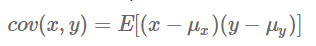

Signo de la Covarianza

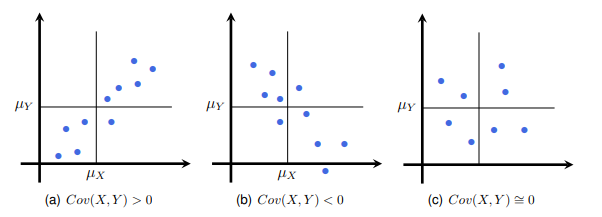

El valor (magnitud) de la covarianza depende las unidades en que se miden las variables.  <br>Si las escalas de medida de las variables fueran muy diferentes, la variabilidad estaría dominada por las variables con mayores magnitudes.

La Correlación se define como la covarianza de los datos estandarizados, por lo que evita el problema de las diferencias en las escalas de medición. Se obtiene dividiendo la covarianza de dos variables por el producto de sus desvíos estándar.

*Correlación (poblacional):*

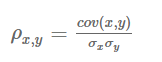

Los valores del coeficiente de correlación van de -1 a 1. Cuanto más cerca esté de 1 (o -1), más estrechamente relacionadas estarán las dos variables. El signo positivo significa la dirección de la correlación, es decir, si una de las variables aumenta, se supone que la otra también aumentará.

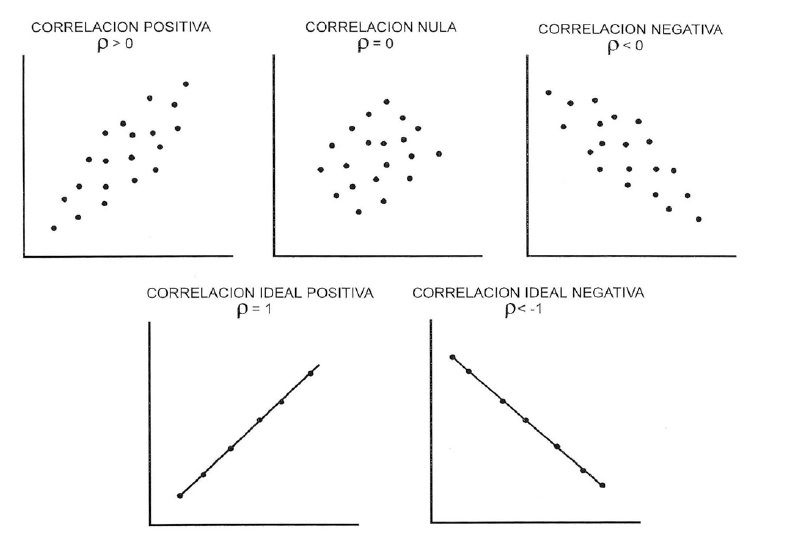

¿Cómo estimar el coeficiente de correlación poblacional desconocido? Con un estimador muestral.

Coeficiente de Correlación de Pearson:

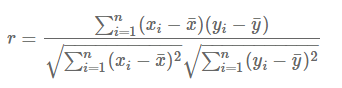


Armemos un ejemplo con datos simulados:

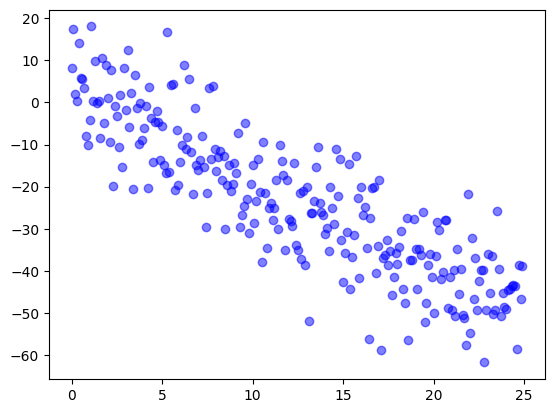

In [72]:
#Valores de X
x = np.arange(0, 25, 0.1)  # vector de numeros de 0 a 25 con intervalos de 0.5

#ruido gausiano
ruido=np.random.randn(x.shape[0])

# y= a x + b + c*ruido gausiano
a=-2
b=1
c=9

y= a*x + b + c*ruido

#scatter plot
plt.scatter(x,y,label='data', color='blue',alpha=0.5)

Podemos calcular la correlacion con la librería de Numpy

In [73]:
covariance = np.cov(x, y)[0][1]
print(f"Covarianza: cov={covariance}")

Covarianza: cov=-110.42867891349897


In [74]:
corr_pearson = np.corrcoef(x, y)[0][1]
print(f"Correlación Pearson: r={corr_pearson}")

Correlación Pearson: r=-0.861120042173292


Volvamos al problema puntual de la correlación entre la popularidad y la bailabilidad promedio. Usemos la función *pearsonr* de la librería Scipy para calcularla. Este módulo contiene un gran número de distribuciones de probabilidad, así como una creciente biblioteca de funciones estadísticas.

In [75]:
# Correlación de Pearson con Scipy
corr, _ = pearsonr(df_1['popularity'],  df_1['danceability'])
print('Pearsons correlation: %.3f' % corr)


Pearsons correlation: 0.899


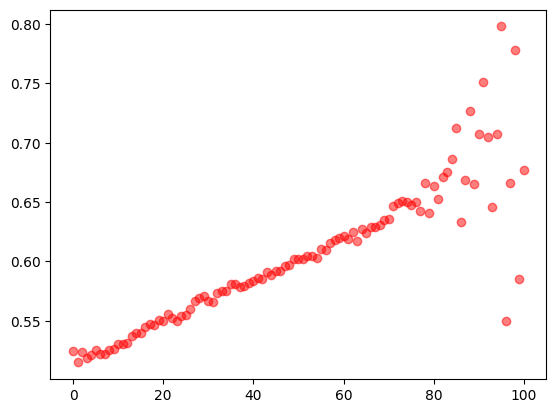

In [78]:
plt.scatter(x='popularity', y='danceability', data=df_1, color='red',alpha=0.5)


Veamos ahora la correlación entre todas las variables del dataset original. Calculemos primero la matriz de covarianzas y luego la de correlaciones

In [27]:
#Calculo la Covarianza
numeric_cols = df_tracks.select_dtypes(include=np.number).columns
matriz_cov = df_tracks[numeric_cols].cov()
matriz_cov

,popularity,duration_ms,explicit,year,month,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,337.480501,6.433999e+04,0.798591,247.847035,10.038787,0.570613,1.399111,0.989121,30.575250,-0.293124,-0.156503,-2.376741,-1.159387,-0.165042,0.021979,39.021074,0.754133
duration_ms,64339.985235,1.600885e+10,-434.985961,156400.154884,-1864.430546,-2529.757145,791.291308,2059.744040,216.819767,-1656.265317,-2862.698508,-2843.905550,2339.208040,49.836456,-5320.716158,-4557.715086,2248.146500
explicit,0.798591,-4.349860e+02,0.042142,0.977079,0.065774,0.005123,0.006365,0.007898,0.140630,-0.005037,0.003776,-0.010671,-0.003699,-0.000496,-0.000875,0.035102,0.004317
year,247.847035,1.564002e+05,0.977079,521.267473,21.566152,0.859904,2.647310,1.901479,51.943860,-0.880144,-0.336369,-4.201864,-1.352695,-0.088437,-0.145277,81.983507,1.257948
month,10.038787,-1.864431e+03,0.065774,21.566152,15.927859,0.046197,0.134935,0.160244,3.150408,-0.063341,0.010432,-0.169862,-0.030382,0.012389,-0.010649,2.940759,0.043723
danceability,0.570613,-2.529757e+03,0.005123,0.859904,0.046197,0.027590,0.010108,0.011004,0.212552,-0.003522,0.005956,-0.014077,-0.010014,-0.003251,0.022605,-0.201628,0.011490
energy,1.399111,7.912913e+02,0.006365,2.647310,0.134935,0.010108,0.063465,0.032179,0.980481,-0.007793,-0.002425,-0.062870,-0.013166,0.005787,0.024166,1.725346,0.022527
key,0.989121,2.059744e+03,0.007898,1.901479,0.160244,0.011004,0.032179,12.386339,0.485563,-0.216070,-0.000655,-0.033656,-0.006364,-0.004394,0.018130,0.513701,0.014867
loudness,30.575250,2.168198e+02,0.140630,51.943860,3.150408,0.212552,0.980481,0.485563,25.901258,-0.097636,-0.152997,-0.922155,-0.447257,0.027701,0.361215,28.673229,0.395832
mode,-0.293124,-1.656265e+03,-0.005037,-0.880144,-0.063341,-0.003522,-0.007793,-0.216070,-0.097636,0.224784,-0.001535,0.009744,-0.001266,0.000613,0.001402,0.111072,-0.003565


In [28]:
#Calculo la correlación
numeric_cols = df_tracks.select_dtypes(include=np.number).columns
matriz_corr = df_tracks[numeric_cols].corr(method = 'pearson')
matriz_corr

,popularity,duration_ms,explicit,year,month,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,0.027681,0.211758,0.590921,0.136924,0.187000,0.302315,0.015299,0.327028,-0.033655,-0.047357,-0.370882,-0.236487,-0.048740,0.004643,0.071364,0.086759
duration_ms,0.027681,1.000000,-0.016747,0.054141,-0.003692,-0.120371,0.024825,0.004626,0.000337,-0.027610,-0.125771,-0.064434,0.069278,0.002137,-0.163202,-0.001210,0.037552
explicit,0.211758,-0.016747,1.000000,0.208468,0.080281,0.150229,0.123076,0.010932,0.134603,-0.051754,0.102258,-0.149018,-0.067520,-0.013114,-0.016539,0.005745,0.044447
year,0.590921,0.054141,0.208468,1.000000,0.236681,0.226748,0.460264,0.023664,0.447037,-0.081309,-0.081898,-0.527581,-0.222010,-0.021015,-0.024695,0.120643,0.116445
month,0.136924,-0.003692,0.080281,0.236681,1.000000,0.069688,0.134208,0.011409,0.155106,-0.033475,0.014530,-0.122010,-0.028526,0.016841,-0.010355,0.024756,0.023154
danceability,0.187000,-0.120371,0.150229,0.226748,0.069688,1.000000,0.241563,0.018824,0.251436,-0.044719,0.199310,-0.242951,-0.225900,-0.106168,0.528150,-0.040783,0.146196
energy,0.302315,0.024825,0.123076,0.460264,0.134208,0.241563,1.000000,0.036294,0.764735,-0.065246,-0.053506,-0.715412,-0.195839,0.124632,0.372276,0.230099,0.188983
key,0.015299,0.004626,0.010932,0.023664,0.011409,0.018824,0.036294,1.000000,0.027109,-0.129491,-0.001035,-0.027414,-0.006776,-0.006774,0.019992,0.004904,0.008928
loudness,0.327028,0.000337,0.134603,0.447037,0.155106,0.251436,0.764735,0.027109,1.000000,-0.040464,-0.167112,-0.519423,-0.329306,0.029529,0.275448,0.189288,0.164377
mode,-0.033655,-0.027610,-0.051754,-0.081309,-0.033475,-0.044719,-0.065246,-0.129491,-0.040464,1.000000,-0.017992,0.058918,-0.010008,0.007009,0.011474,0.007871,-0.015892


<Axes: >

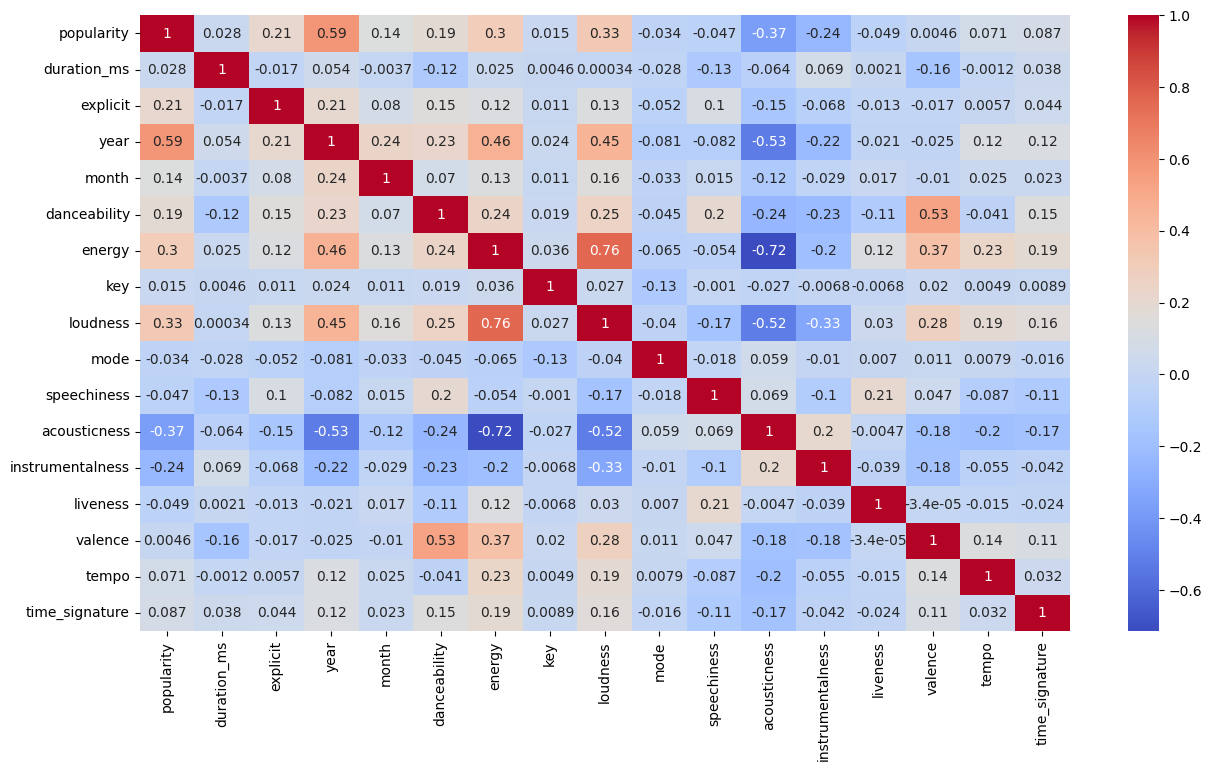

In [29]:
#Grafico la matriz de correlación en un Heatmap

plt.figure(figsize = (15,8))
sns.heatmap(matriz_corr, annot = True, cmap='coolwarm')

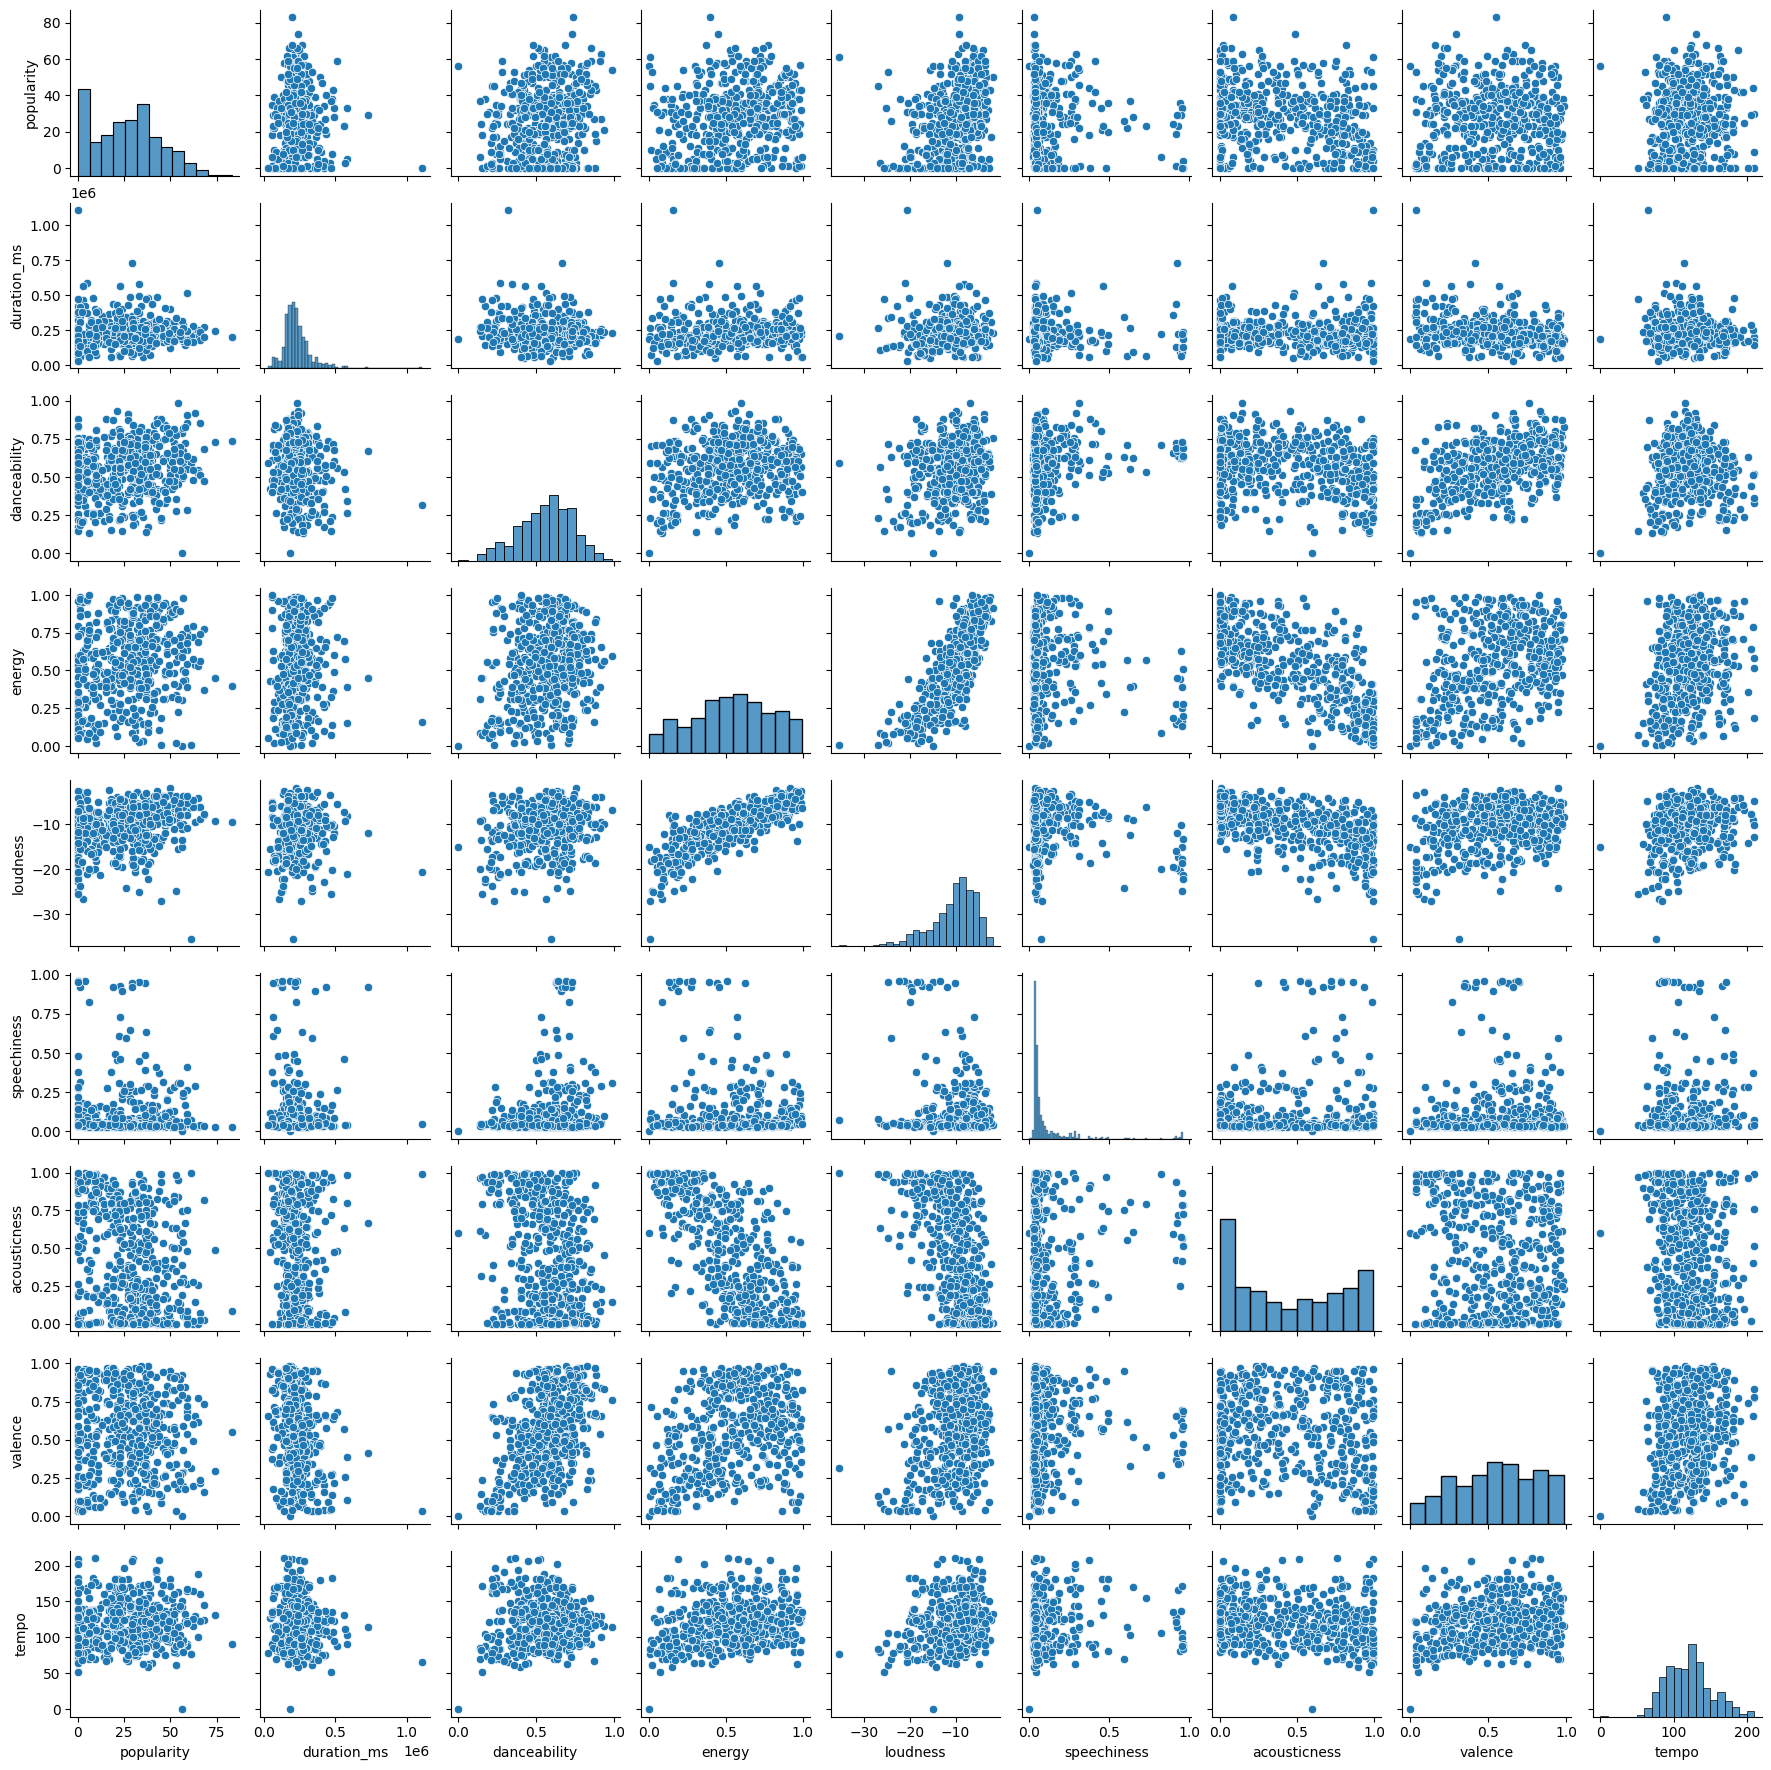

In [30]:
#Creo una lista para seleccionar algunas columnas
sel_col = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness','valence', 'tempo']

#Seteo una semilla
random.seed(10)

#Grafico un pairplot
sns.pairplot(df_tracks[sel_col].sample(500), height=2)

## Correlacion != Causalidad

**Que dos variables tiengan un alto índice de correlación no significa que una cause a la otra.**

Las correlaciones pueden suceder por otros motivos como por ejemplo el azar.

¡Las relaciones de causalidad son dificiles de encontrar y de demostrar!

https://www.tylervigen.com/spurious-correlations

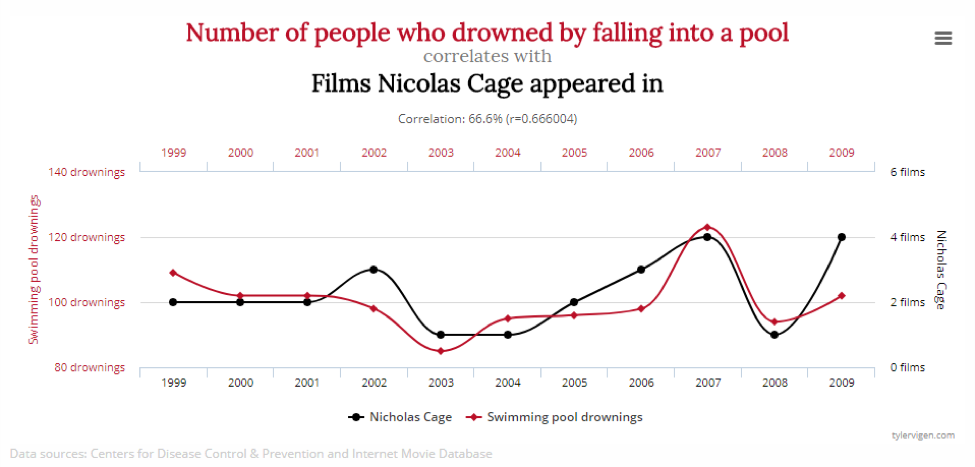

## Artists data

Analicemos ahora el dataset de artistas.

In [31]:
df_artists.head()

,id,followers,genres,name,popularity
0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0


In [32]:
df_artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104349 entries, 0 to 1104348
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   id          1104349 non-null  object 
 1   followers   1104336 non-null  float64
 2   genres      1104349 non-null  object 
 3   name        1104346 non-null  object 
 4   popularity  1104349 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 42.1+ MB


### ¿Cuáles son los artistas más populares?

In [33]:
artists_popular = df_artists.sort_values(by=['popularity'], ascending=False).reset_index()
artists_popular[:10]

,index,id,followers,genres,name,popularity
0,144481,1uNFoZAHBGtllmzznpCI3s,44606973.0,"['canadian pop', 'pop', 'post-teen pop']",Justin Bieber,100
1,115489,4q3ewBCX7sLwd24euuV69X,32244734.0,"['latin', 'reggaeton', 'trap latino']",Bad Bunny,98
2,126338,06HL4z0CvFAxyc27GXpf02,38869193.0,"['pop', 'post-teen pop']",Taylor Swift,98
3,313676,3TVXtAsR1Inumwj472S9r4,54416812.0,"['canadian hip hop', 'canadian pop', 'hip hop'...",Drake,98
4,115490,4MCBfE4596Uoi2O4DtmEMz,16996777.0,"['chicago rap', 'melodic rap']",Juice WRLD,96
5,144484,3Nrfpe0tUJi4K4DXYWgMUX,31623813.0,"['k-pop', 'k-pop boy group']",BTS,96
6,144483,1Xyo4u8uXC1ZmMpatF05PJ,31308207.0,"['canadian contemporary r&b', 'canadian pop', ...",The Weeknd,96
7,144487,6M2wZ9GZgrQXHCFfjv46we,24123468.0,"['dance pop', 'pop', 'uk pop']",Dua Lipa,95
8,144486,1vyhD5VmyZ7KMfW5gqLgo5,27286822.0,"['latin', 'reggaeton', 'reggaeton colombiano',...",J Balvin,95
9,144485,66CXWjxzNUsdJxJ2JdwvnR,61301006.0,"['pop', 'post-teen pop']",Ariana Grande,95


Observamos que el top ten de canciones y artistas difiere. Justin Bieber es el artista más popular, aunque sus canciones no son las más populares ahora mismo.

## Detección de valores faltantes (otra vez)

Si miramos la cabecera de los datos, observamos también que, en muchas filas, la columna "géneros" es una lista vacía, lo que también puede considerarse como valores missing. Para manejar este tipo de situación es importante ver la proporción de tales filas con respecto a la forma general del conjunto de datos.

In [34]:
missing_genre = len(df_artists[df_artists["genres"]=='[]'])/len(df_artists)
print(f"Proporcion de géneros vacíos: {round(missing_genre*100)}%")

Proporcion de géneros vacíos: 73%


Para este caso concreto, crearemos y realizaremos nuestro análisis en un nuevo conjunto de datos con sólo aquellas filas que contengan algún valor en la columna "géneros".

In [35]:
df_genre=df_artists[df_artists["genres"]!='[]']
df_genre.head()

,id,followers,genres,name,popularity
45,0VLMVnVbJyJ4oyZs2L3Yl2,71.0,['carnaval cadiz'],Las Viudas De Los Bisabuelos,6
46,0dt23bs4w8zx154C5xdVyl,63.0,['carnaval cadiz'],Los De Capuchinos,5
47,0pGhoB99qpEJEsBQxgaskQ,64.0,['carnaval cadiz'],Los “Pofesionales”,7
48,3HDrX2OtSuXLW5dLR85uN3,53.0,['carnaval cadiz'],Los Que No Paran De Rajar,6
136,22mLrN5fkppmuUPsHx6i2G,59.0,"['classical harp', 'harp']",Vera Dulova,3


## Creación de nuevos registros

Observamos que la columna 'géneros' tiene una lista pasada como valor (que en realidad es un string). Vamos a dividir estas listas en valores individuales. Para esta tarea, utilizaremos una función muy especial de pandas, llamada *explode()*.

* La función *explode()* divide la lista por cada elemento y crea una nueva fila para cada elemento.

In [36]:
df_sort_genres=pd.DataFrame(df_genre.assign(genres=df_genre.genres.str.split(",")).explode('genres'))
df_sort_genres.head(15)

,id,followers,genres,name,popularity
45,0VLMVnVbJyJ4oyZs2L3Yl2,71.0,['carnaval cadiz'],Las Viudas De Los Bisabuelos,6
46,0dt23bs4w8zx154C5xdVyl,63.0,['carnaval cadiz'],Los De Capuchinos,5
47,0pGhoB99qpEJEsBQxgaskQ,64.0,['carnaval cadiz'],Los “Pofesionales”,7
48,3HDrX2OtSuXLW5dLR85uN3,53.0,['carnaval cadiz'],Los Que No Paran De Rajar,6
136,22mLrN5fkppmuUPsHx6i2G,59.0,['classical harp',Vera Dulova,3
136,22mLrN5fkppmuUPsHx6i2G,59.0,'harp'],Vera Dulova,3
141,1OsJZxSshQD4BCg1VtwxsN,155.0,['classical contralto'],Anna Larsson,19
142,5JRTWjFYThNR99D7IOEmn0,106.0,['british choir'],BBC Chorus,16
144,4sTTEheJxmjwv9TmrHOaPz,288.0,"[""children's story""]",Honor Blackman,15
148,3zQdpHMTdJnV4aCzGqCBYK,3918.0,['classic persian pop',Javad Maroufi,26


Sustituimos los corchetes por espacios en blanco " " para obtener sólo las palabras clave.

In [37]:
df_sort_genres['genres']=df_sort_genres.genres.str.replace('[',' ')
df_sort_genres['genres']=df_sort_genres.genres.str.replace(']',' ')

Veamos el top 10 de géneros más frecuentes

In [38]:
n = 10
top_10=pd.DataFrame(df_sort_genres['genres'].value_counts()[:n]).reset_index()
top_10.rename(columns = {'index':'Genres','genres':'Total_Count'}, inplace = True)
top_10

,Total_Count,count
0,'dance pop',551
1,'latin',483
2,'electro house',478
3,'pop',461
4,'edm',455
5,'hip hop',455
6,'electropop',432
7,'indie rock',411
8,'classical performance',407
9,'tropical',402


## Joins

"Joinear", "mergear" o cruzar dos datasets, implica elegir una o más columnas que estos tengan en común y utilizarlas para cruzar ambas tablas en base a la coincidencia de valores entre ambas. Existen varios tipos de _joins_ según cuál es el resultado que nos interesa obtener al final con la cruza:

* **left join**: preserva el 100% de las filas que tiene la tabla _de la izquierda_ del merge, y agrega las columnas del dataset _de la derecha_ con los valores (cuando hay una coincidencia) o las llena con valores nulos (cuando no hay coincidencia). Si el dataset de la derecha tiene valores para filas que no están presentes en el dataset de la izquierda, simplemente no se utilizan. El dataset resultado tiene la misma cantidad de filas que el dataset de la izquierda.
* **right join**: es igual que el anterior, pero se preservan las filas del dataset de la derecha en lugar de las del de la izquierda.
* **inner join**: sólo se mantienen aquellas filas que coinciden _en ambos datasets_. Si alguna fila no tiene coincidencia en uno de los dos, se descarta. El dataset final tiene igual cantidad o menos filas que el dataset más grande.
* **outer join**: se preservan todas las filas. Si hay coincidencia, se cruzan, y si no hay coincidencia se apilan llenando con valores nulos.

El tipo de join más común que van a utilizar la mayoría de las veces es el **left join**, cuyo caso de uso es "tengo una tabla, y quiero enriquecerla con nuevas columnas".

![](https://donnierock.files.wordpress.com/2014/03/udqpd.jpg)

Como prueba, joiniemos el dataset de tracks y artistas. Apliquemos algunas transformaciones al dataset de artistas para que la unión sea posible. Podemos valernos de la columna de nombre del artista como llave, pues esta presente en los dos datasets, pero necesitamos eliminar algunos string que ensucian a la variable. También es conveniente renombrar algunas de las columnas que poseen el mismo nombre ambos dataset, para no generar confusiones.  

In [39]:
reemplazos = [ "[", "]", "'", "'"]
for i in reemplazos:
    df_tracks['artists']=df_tracks.artists.str.replace( i ,'')

df_tracks.rename(columns = {'name': 'track_name'}, inplace = True)

Realizamos el join

In [40]:
df_join = pd.merge( df_tracks,
                   df_artists[['name', 'followers']],
                   left_on =  'artists',
                   right_on='name',
                   how = 'left')

Mostramos algunos de sus valores. Noten que, sólo para fines ilustrativos, borramos algunos valores duplicados tomando como llaves (key) las columnas nombre del artista y followers. Para ello usamos la función [`drop_duplicates()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html) (prestar atención al parámetro *subset* y *keep*)

In [41]:
df_join.drop_duplicates(subset = ['artists','followers'], keep='first').sort_values('followers', ascending=False)

,id,track_name,popularity,duration_ms,explicit,artists,id_artists,release_date,year,month,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,name,followers
90768,1VdZ0vKfR5jneCmWIUAMxK,The A Team,77,258373,0,Ed Sheeran,['6eUKZXaKkcviH0Ku9w2n3V'],2011-09-09,2011,9,...,1,0.0367,0.6690,0.000000,0.180,0.407,84.996,4,Ed Sheeran,78900234.0
93815,6NmCCgnQcxKHPOAKgd9Nth,Baby I,62,197600,0,Ariana Grande,['66CXWjxzNUsdJxJ2JdwvnR'],2013-01-01,2013,1,...,1,0.0328,0.0152,0.000000,0.354,0.542,101.975,4,Ariana Grande,61301006.0
88642,3QLjDkgLh9AOEHlhQtDuhs,Best I Ever Had,76,257690,1,Drake,['3TVXtAsR1Inumwj472S9r4'],2009-01-01,2009,1,...,1,0.3750,0.1900,0.000000,0.134,0.558,162.361,4,Drake,54416812.0
88707,6eDApnV9Jdb1nYahOlbbUh,One Time,71,215867,0,Justin Bieber,['1uNFoZAHBGtllmzznpCI3s'],2009-01-01,2009,1,...,0,0.0372,0.0631,0.000071,0.082,0.762,145.999,4,Justin Bieber,44606973.0
75183,01xhMrdCefADl7HSttJaf7,Infinite,57,251707,1,Eminem,['7dGJo4pcD2V6oG8kP0tJRR'],1996-11-12,1996,11,...,0,0.1910,0.2930,0.000000,0.217,0.573,82.019,4,Eminem,43747833.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646883,65hdygJXXOBGKS76EKvxth,醒不来的梦,50,232297,0,回小仙,['27kWsk6mk6DeqQhdOHsyej'],2020-09-29,2020,9,...,0,0.0318,0.4970,0.000000,0.394,0.471,108.012,4,NaN,NaN
646886,7JWoMpoxEl3pZ2CLZxM6ms,天空之外,49,367192,0,解语花,['5SWFVqjJ5POFRF6cudSL3X'],2020-01-19,2020,1,...,1,0.0301,0.5800,0.004830,0.420,0.243,124.990,4,NaN,NaN
646890,4ow9HehIdFii1cggylW2k0,四季予你 - DJ版,47,156393,0,"程響, 阿卓","['7nKA1c1Qn6nI0XA8yburf3', '7g8hOWXtGS16J30CMU...",2020-12-29,2020,12,...,0,0.0446,0.1340,0.002340,0.302,0.908,140.026,4,NaN,NaN
646893,1ZwZsVZUiyFwIHMNpI3ERt,Skyscraper,4,106002,0,Emilie Chin,['4USdOnfLczwUglA3TrdHs2'],2020-02-08,2020,2,...,0,0.0284,0.1130,0.856000,0.104,0.215,120.113,4,NaN,NaN


Notemos que si la columna llave coincide en nombre, **quedará una sola columna**, pero si los nombres son diferentes tendremos una columna duplicada (que no queremos). Por lo tanto procedemos a eliminarla.

In [42]:
df_join = df_join.drop(
    columns=["name"]
)

df_join.columns

Index(['id', 'track_name', 'popularity', 'duration_ms', 'explicit', 'artists',
       'id_artists', 'release_date', 'year', 'month', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'followers'],
      dtype='object')